Saving Screenshot 2026-07-26 110241.png to Screenshot 2026-07-26 110241 (3).png
Original Image


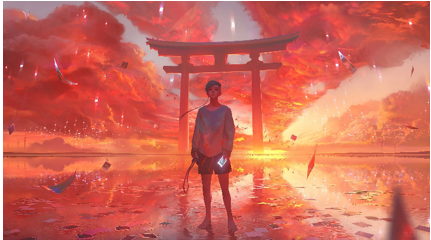

Affine Transformed Image


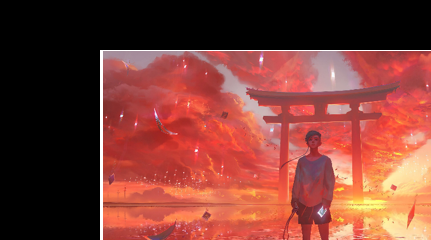

Affine transformed image saved successfully!


In [ ]:
# Import libraries
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload image
uploaded = files.upload()

# Get uploaded file name
image_name = list(uploaded.keys())[0]

# Read the image
img = cv2.imread(image_name)

# Check whether image is loaded
if img is None:
    print("Error: Image not found!")
else:
    # Get image dimensions
    rows, cols = img.shape[:2]

    # Affine transformation matrix (Translation)
    M = np.float32([[1, 0, 100],
                    [0, 1, 50]])

    # Apply affine transformation
    affine_img = cv2.warpAffine(img, M, (cols, rows))

    # Display images
    print("Original Image")
    cv2_imshow(img)

    print("Affine Transformed Image")
    cv2_imshow(affine_img)

    # Save transformed image
    cv2.imwrite("Affine_Transformed.jpg", affine_img)

    print("Affine transformed image saved successfully!")

Saving Screenshot 2026-07-26 110241.png to Screenshot 2026-07-26 110241 (4).png
Original Image


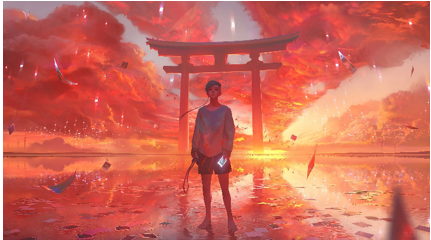

Perspective Transformed Image


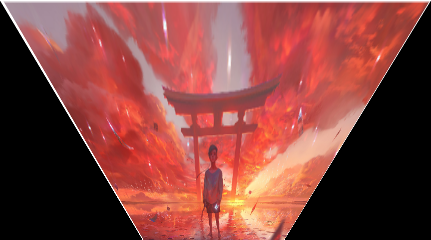

Perspective transformed image saved successfully!


In [ ]:
# Import libraries
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload image
uploaded = files.upload()

# Get uploaded file name
image_name = list(uploaded.keys())[0]

# Read the image
img = cv2.imread(image_name)

# Check if image is loaded
if img is None:
    print("Error: Image not found!")
else:
    # Get image dimensions
    rows, cols = img.shape[:2]

    # Source points (corners of the original image)
    src_points = np.float32([
        [0, 0],
        [cols - 1, 0],
        [0, rows - 1],
        [cols - 1, rows - 1]
    ])

    # Destination points (for perspective transformation)
    dst_points = np.float32([
        [0, 0],
        [cols - 1, 0],
        [int(0.33 * cols), rows - 1],
        [int(0.66 * cols), rows - 1]
    ])

    # Compute perspective transformation matrix
    M = cv2.getPerspectiveTransform(src_points, dst_points)

    # Apply perspective transformation
    perspective_img = cv2.warpPerspective(img, M, (cols, rows))

    # Display images
    print("Original Image")
    cv2_imshow(img)

    print("Perspective Transformed Image")
    cv2_imshow(perspective_img)

    # Save the transformed image
    cv2.imwrite("Perspective_Transformed_Image.jpg", perspective_img)

    print("Perspective transformed image saved successfully!")

In [ ]:
# Import libraries
import cv2
import numpy as np
from google.colab import files

# Upload a video
uploaded = files.upload()

# Get uploaded video name
video_name = list(uploaded.keys())[0]

# Open the uploaded video
cap = cv2.VideoCapture(video_name)

# Perspective transformation points
roi_points = np.float32([
    [150, 200],
    [450, 200],
    [550, 500],
    [50, 500]
])

target_points = np.float32([
    [0, 0],
    [400, 0],
    [400, 600],
    [0, 600]
])

# Perspective transformation matrix
M = cv2.getPerspectiveTransform(roi_points, target_points)

# Video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('Perspective_Transformed_Video.mp4', fourcc, 20.0, (400, 600))

# Process video frame by frame
while True:
    ret, frame = cap.read()

    if not ret:
        break

    # Apply perspective transformation
    transformed = cv2.warpPerspective(frame, M, (400, 600))

    # Save transformed frame
    out.write(transformed)

# Release resources
cap.release()
out.release()

print("Perspective transformed video saved as 'Perspective_Transformed_Video.mp4'")

Saving demonslayer (1).mp4 to demonslayer (1) (4).mp4
Perspective transformed video saved as 'Perspective_Transformed_Video.mp4'


In [ ]:
from IPython.display import Video

Video("Perspective_Transformed_Video.mp4", embed=True)

Saving Screenshot 2026-07-26 110241.png to Screenshot 2026-07-26 110241 (5).png
Original Image


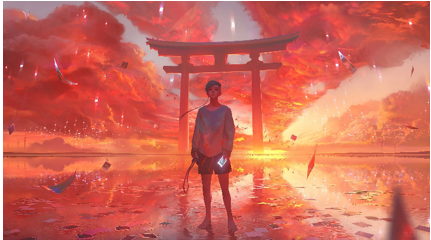

Homography Transformed Image


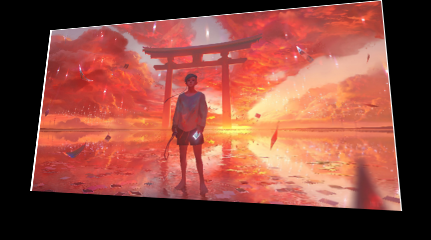

Homography Transformation completed successfully!


In [ ]:
# Import required libraries
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload image
uploaded = files.upload()

# Get uploaded image name
image_name = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_name)

# Check if image is loaded
if img is None:
    print("Error: Unable to load image.")
else:
    # Get image dimensions
    rows, cols = img.shape[:2]

    # Source points (Corners of the original image)
    src_points = np.float32([
        [0, 0],
        [cols - 1, 0],
        [0, rows - 1],
        [cols - 1, rows - 1]
    ])

    # Destination points (Apply Homography)
    dst_points = np.float32([
        [50, 30],
        [cols - 50, 0],
        [30, rows - 50],
        [cols - 30, rows - 30]
    ])

    # Find Homography Matrix
    H, status = cv2.findHomography(src_points, dst_points)

    # Apply Homography Transformation
    homography_img = cv2.warpPerspective(img, H, (cols, rows))

    # Display Images
    print("Original Image")
    cv2_imshow(img)

    print("Homography Transformed Image")
    cv2_imshow(homography_img)

    # Save Output Image
    cv2.imwrite("Transformation_using_Homography_Image.jpg", homography_img)

    print("Homography Transformation completed successfully!")

Saving Screenshot 2026-07-26 110241.png to Screenshot 2026-07-26 110241 (6).png
Original Image


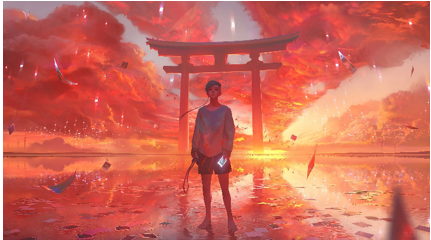

DLT Transformed Image


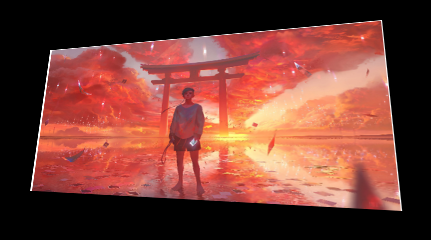

Transformation completed successfully!


In [ ]:
# Import libraries
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload image
uploaded = files.upload()

# Get uploaded image name
image_name = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_name)

if img is None:
    print("Error: Unable to load image.")
else:
    rows, cols = img.shape[:2]

    # Source points
    src_pts = np.float32([
        [0, 0],
        [cols-1, 0],
        [0, rows-1],
        [cols-1, rows-1]
    ])

    # Destination points
    dst_pts = np.float32([
        [50, 50],
        [cols-50, 20],
        [30, rows-50],
        [cols-30, rows-30]
    ])

    # DLT (Homography) Matrix
    H = cv2.getPerspectiveTransform(src_pts, dst_pts)

    # Apply Transformation
    transformed = cv2.warpPerspective(img, H, (cols, rows))

    # Display images
    print("Original Image")
    cv2_imshow(img)

    print("DLT Transformed Image")
    cv2_imshow(transformed)

    # Save image
    cv2.imwrite("DLT_Transformation.jpg", transformed)

    print("Transformation completed successfully!")